In [1]:
# =====================================================
# Exploratory Data Analysis - Rider Churn Project
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# =====================================================
# Load Cleaned Datasets
# =====================================================

riders = pd.read_csv(
    "../data/processed/riders_clean.csv",
    parse_dates=["signup_date"]
)

trips = pd.read_csv(
    "../data/processed/trips_clean.csv",
    parse_dates=["pickup_time", "dropoff_time"]
)

drivers = pd.read_csv(
    "../data/processed/drivers_clean.csv",
    parse_dates=["signup_date", "last_active"]
)

sessions = pd.read_csv(
    "../data/processed/sessions_clean.csv",
    parse_dates=["session_time"]
)

promotions = pd.read_csv(
    "../data/processed/promotions_clean.csv",
    parse_dates=["start_date", "end_date"]
)

In [3]:
# =====================================================
# Helper Function
# =====================================================

def dataset_overview(df, name):
    print("=" * 60)
    print(f"{name.upper()} DATASET OVERVIEW")
    print("=" * 60)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    display(df.head())

In [4]:
# =====================================================
# EDA 1: Riders Dataset
# =====================================================

dataset_overview(riders, "Riders")

RIDERS DATASET OVERVIEW
Shape: (10000, 9)

Columns:
['user_id', 'signup_date', 'loyalty_status', 'age', 'city', 'avg_rating_given', 'referred_by', 'is_referred', 'is_churned']

Missing values:
user_id             0
signup_date         0
loyalty_status      0
age                 0
city                0
avg_rating_given    0
referred_by         0
is_referred         0
is_churned          0
dtype: int64

Duplicate rows: 0


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,referred_by,is_referred,is_churned
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,R00001,1,0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,Unknown,0,1
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,Unknown,0,1
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,Unknown,0,0
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,R00002,1,0


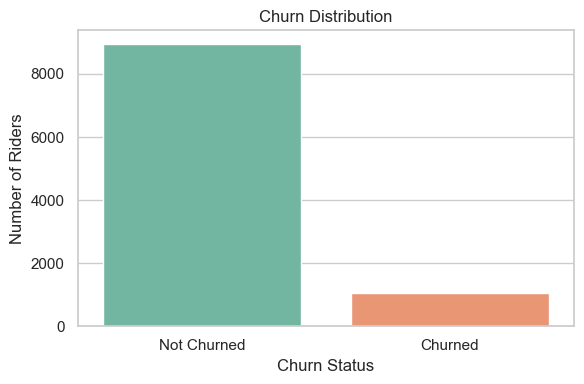

In [5]:
# Churn Distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=riders,
    x="is_churned",
    hue="is_churned",
    palette="Set2",
    legend=False
)

plt.title("Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Riders")
plt.xticks([0, 1], ["Not Churned", "Churned"])

plt.tight_layout()
plt.show()

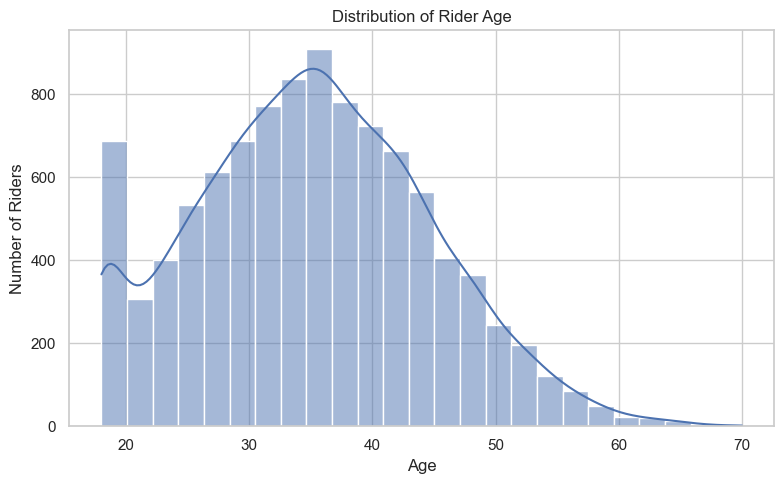

In [6]:
# Rider Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=riders,
    x="age",
    bins=25,
    kde=True
)

plt.title("Distribution of Rider Age")
plt.xlabel("Age")
plt.ylabel("Number of Riders")

plt.tight_layout()
plt.show()

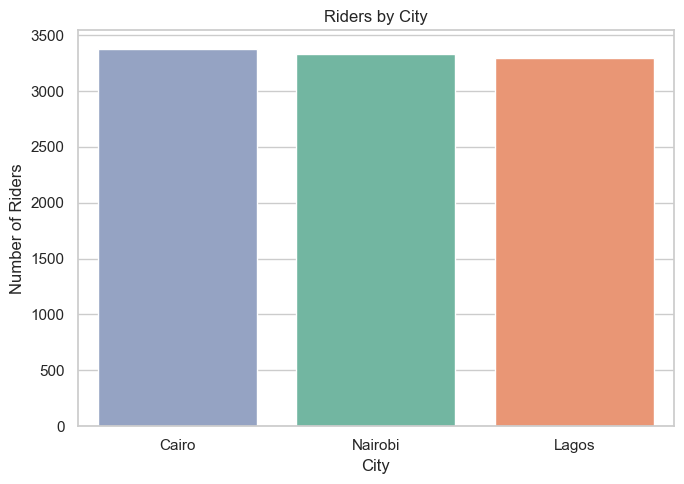

In [7]:
# Riders by City

plt.figure(figsize=(7, 5))

sns.countplot(
    data=riders,
    x="city",
    hue="city",
    order=riders["city"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Riders by City")
plt.xlabel("City")
plt.ylabel("Number of Riders")

plt.tight_layout()
plt.show()

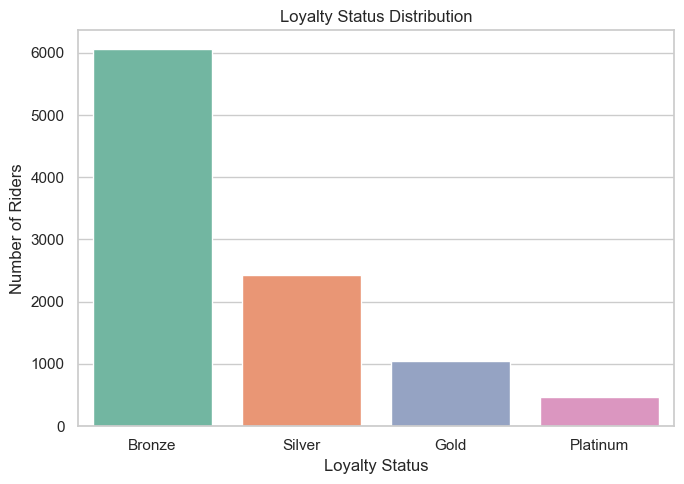

In [8]:
# Loyalty Status Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=riders,
    x="loyalty_status",
    hue="loyalty_status",
    order=riders["loyalty_status"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Loyalty Status Distribution")
plt.xlabel("Loyalty Status")
plt.ylabel("Number of Riders")

plt.tight_layout()
plt.show()

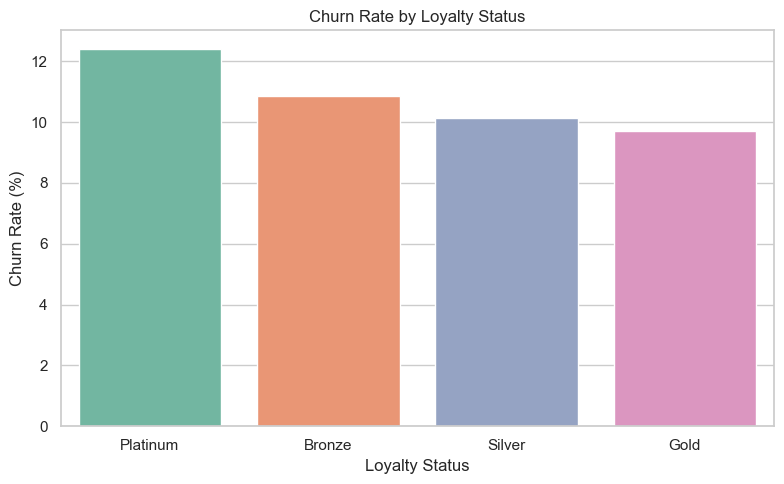

,loyalty_status,is_churned
2,Platinum,12.393162
0,Bronze,10.846954
3,Silver,10.144330
1,Gold,9.714286


In [9]:
# Churn Rate by Loyalty Status

churn_by_loyalty = (
    riders.groupby("loyalty_status")["is_churned"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("is_churned", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_by_loyalty,
    x="loyalty_status",
    y="is_churned",
    hue="loyalty_status",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

display(churn_by_loyalty)

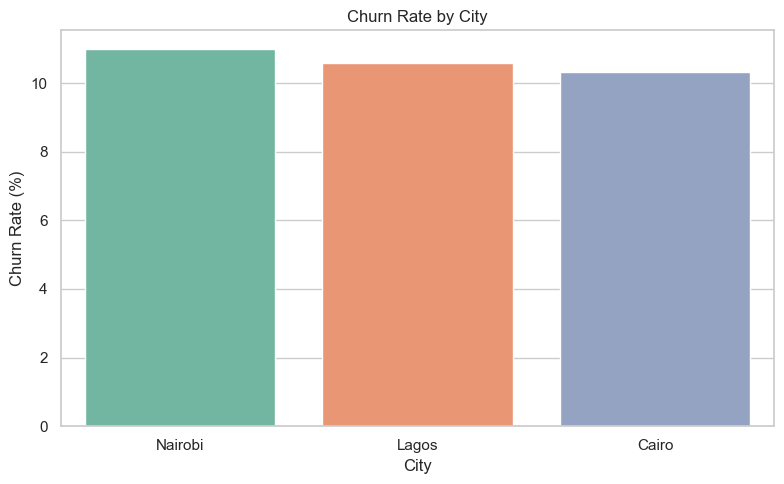

,city,is_churned
2,Nairobi,10.990991
1,Lagos,10.588592
0,Cairo,10.314167


In [10]:
# Churn Rate by City

churn_by_city = (
    riders.groupby("city")["is_churned"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("is_churned", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_by_city,
    x="city",
    y="is_churned",
    hue="city",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

display(churn_by_city)

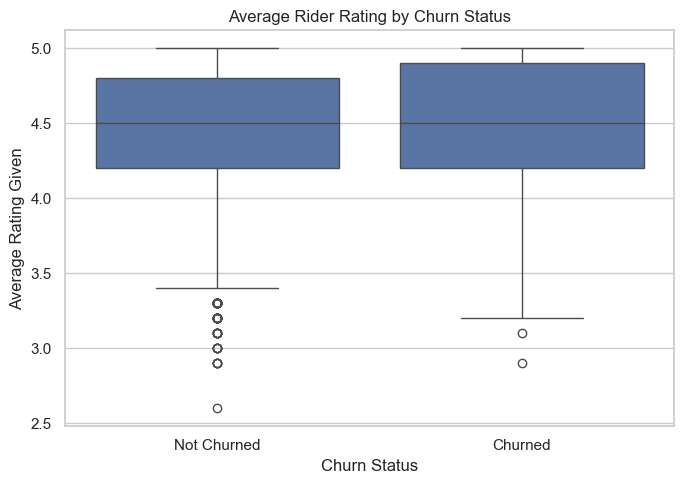

In [11]:
# Average Rating by Churn Status

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=riders,
    x="is_churned",
    y="avg_rating_given"
)

plt.title("Average Rider Rating by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Rating Given")
plt.xticks([0, 1], ["Not Churned", "Churned"])

plt.tight_layout()
plt.show()

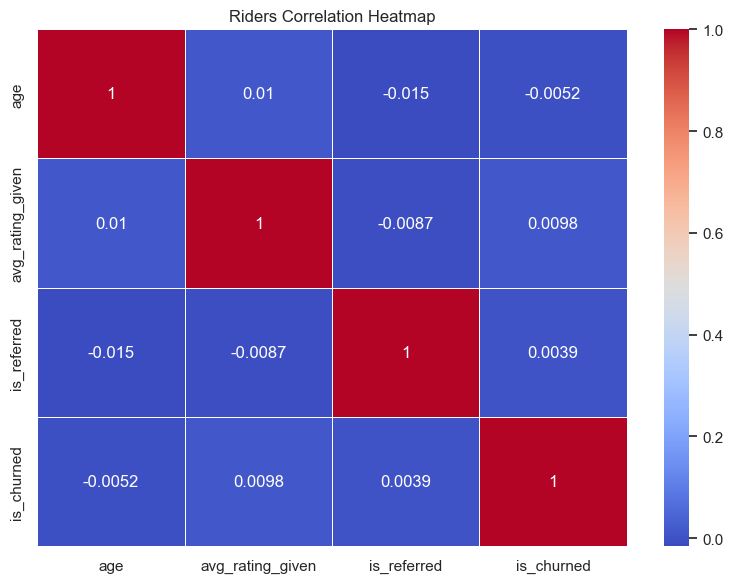

In [12]:
# Correlation Heatmap for Riders

numeric_cols = riders.select_dtypes(include="number")

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Riders Correlation Heatmap")

plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# EDA 2: Trips Dataset
# =====================================================

dataset_overview(trips, "Trips")

TRIPS DATASET OVERVIEW
Shape: (200000, 17)

Columns:
['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip', 'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city', 'loyalty_status', 'trip_duration_minutes']

Missing values:
trip_id                  0
user_id                  0
driver_id                0
fare                     0
surge_multiplier         0
tip                      0
payment_type             0
pickup_time              0
dropoff_time             0
pickup_lat               0
pickup_lng               0
dropoff_lat              0
dropoff_lng              0
weather                  0
city                     0
loyalty_status           0
trip_duration_minutes    0
dtype: int64

Duplicate rows: 0


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status,trip_duration_minutes
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze,52.0
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold,13.0
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze,16.0
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze,5.0
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold,30.0


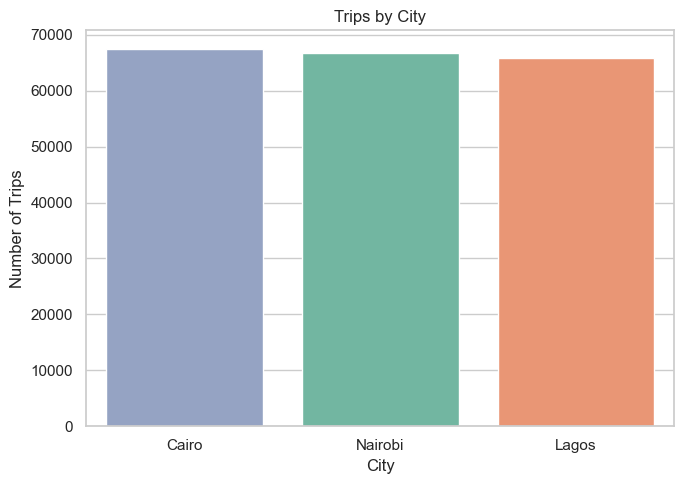

In [14]:
# Trips by City

plt.figure(figsize=(7, 5))

sns.countplot(
    data=trips,
    x="city",
    hue="city",
    order=trips["city"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Trips by City")
plt.xlabel("City")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

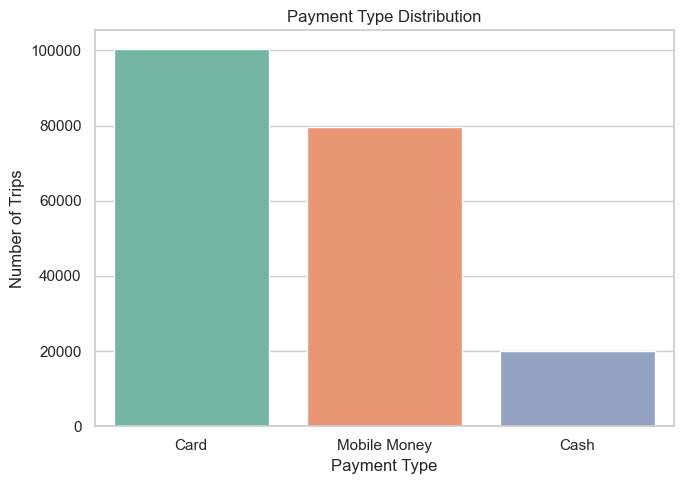

In [15]:
# Payment Type Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=trips,
    x="payment_type",
    hue="payment_type",
    order=trips["payment_type"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

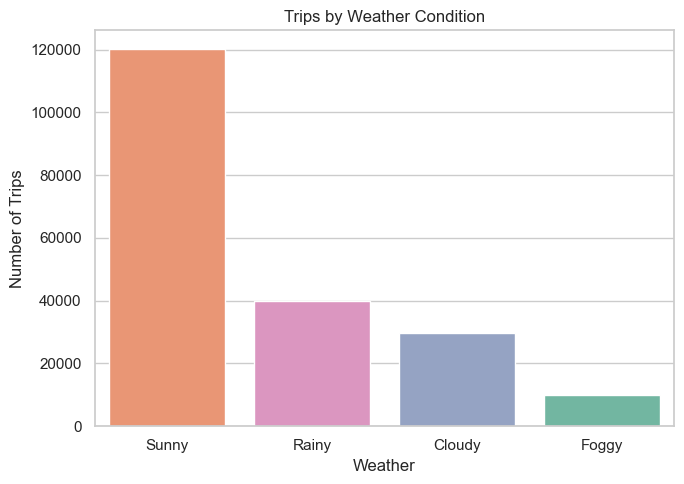

In [16]:
# Weather Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=trips,
    x="weather",
    hue="weather",
    order=trips["weather"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Trips by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

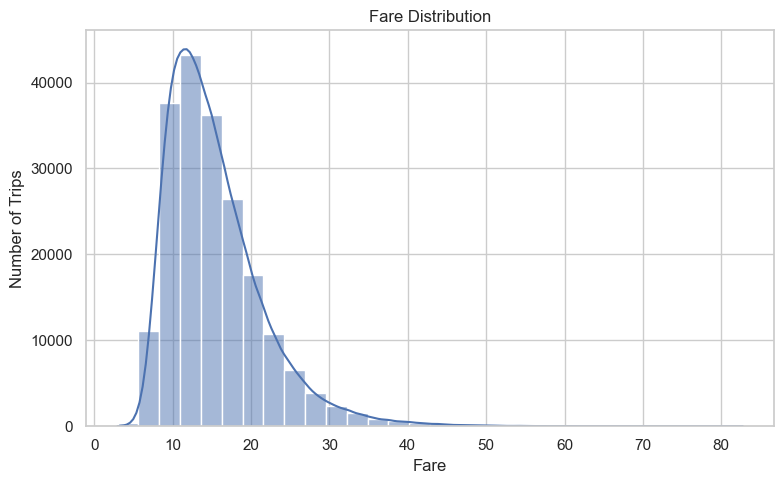

In [17]:
# Fare Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=trips,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

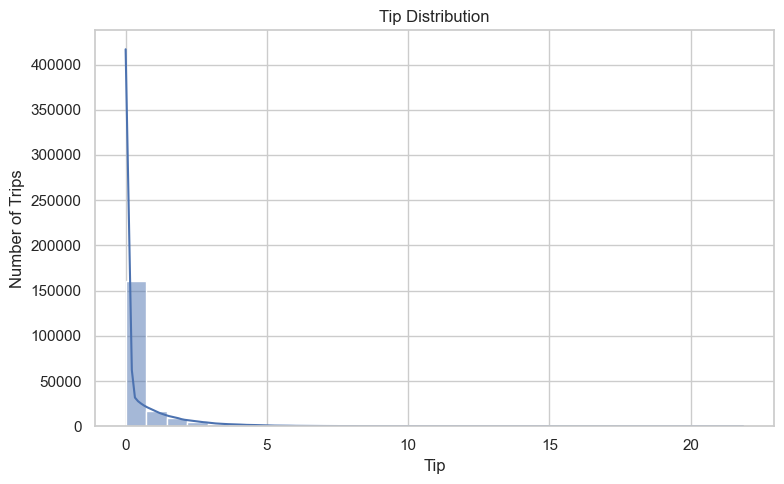

In [18]:
# Tip Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=trips,
    x="tip",
    bins=30,
    kde=True
)

plt.title("Tip Distribution")
plt.xlabel("Tip")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

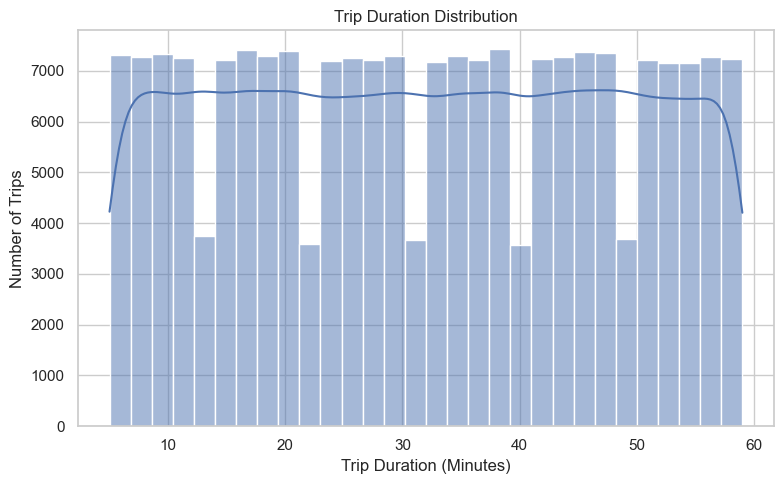

In [19]:
# Trip Duration Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=trips,
    x="trip_duration_minutes",
    bins=30,
    kde=True
)

plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

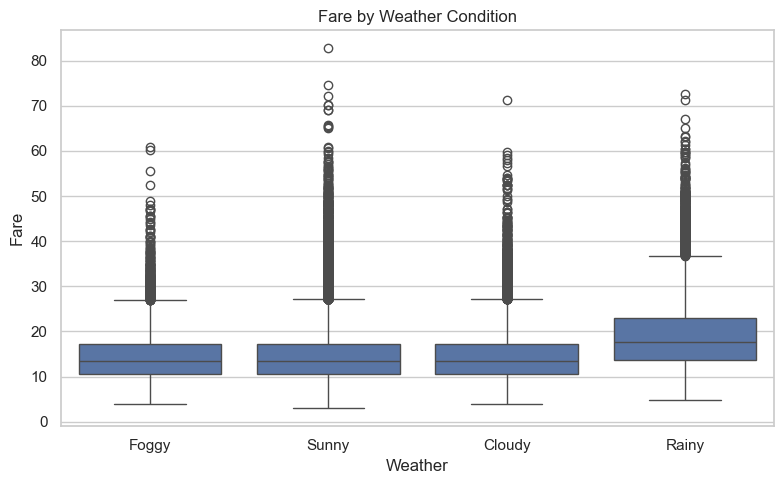

In [20]:
# Fare by Weather

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=trips,
    x="weather",
    y="fare"
)

plt.title("Fare by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

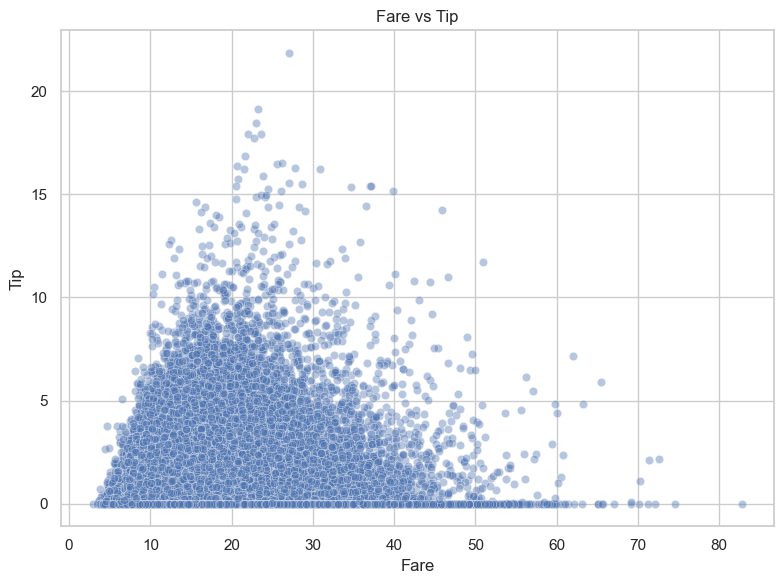

In [21]:
# Fare vs Tip

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=trips,
    x="fare",
    y="tip",
    alpha=0.4
)

plt.title("Fare vs Tip")
plt.xlabel("Fare")
plt.ylabel("Tip")

plt.tight_layout()
plt.show()

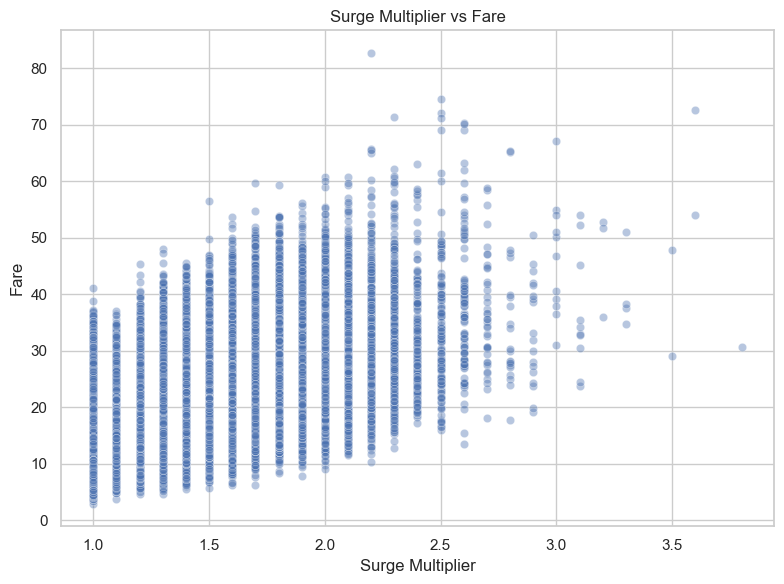

In [22]:
# Surge Multiplier vs Fare

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=trips,
    x="surge_multiplier",
    y="fare",
    alpha=0.4
)

plt.title("Surge Multiplier vs Fare")
plt.xlabel("Surge Multiplier")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

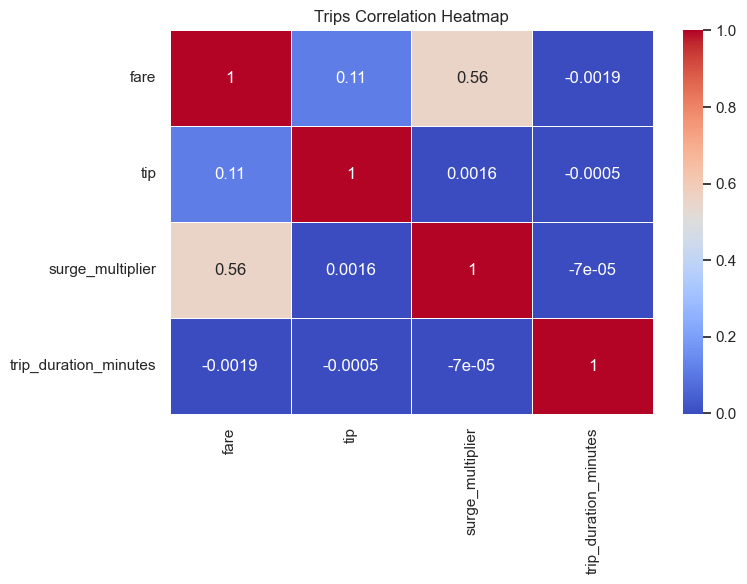

In [23]:
# Trips Correlation Heatmap

trip_numeric_cols = [
    "fare",
    "tip",
    "surge_multiplier",
    "trip_duration_minutes"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    trips[trip_numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Trips Correlation Heatmap")

plt.tight_layout()
plt.show()

In [24]:
# =====================================================
# EDA 3: Sessions Dataset
# =====================================================

dataset_overview(sessions, "Sessions")

SESSIONS DATASET OVERVIEW
Shape: (50000, 8)

Columns:
['session_id', 'rider_id', 'session_time', 'time_on_app', 'pages_visited', 'converted', 'city', 'loyalty_status']

Missing values:
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64

Duplicate rows: 0


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 16:52:06+00:00,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 05:05:22+00:00,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 21:12:25+00:00,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:26:25+00:00,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:17:22+00:00,4,1,0,Lagos,Bronze


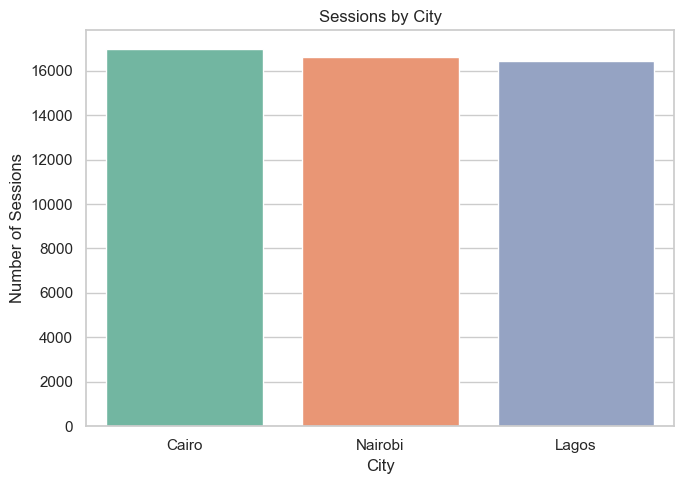

In [25]:
# Sessions by City

plt.figure(figsize=(7, 5))

sns.countplot(
    data=sessions,
    x="city",
    hue="city",
    order=sessions["city"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Sessions by City")
plt.xlabel("City")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

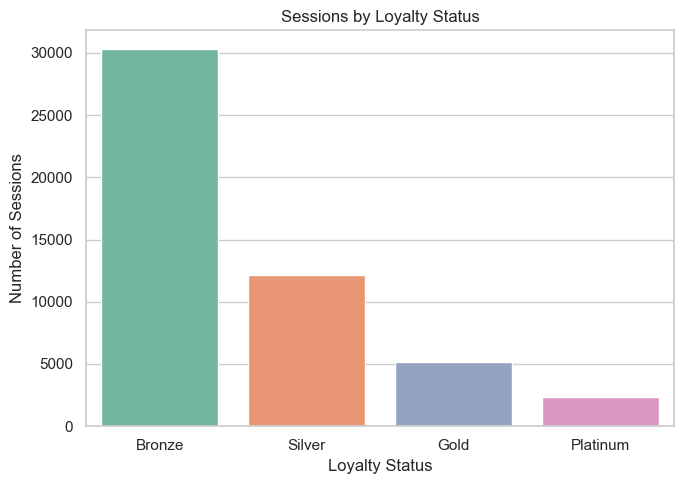

In [26]:
# Sessions by Loyalty Status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=sessions,
    x="loyalty_status",
    hue="loyalty_status",
    order=sessions["loyalty_status"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Sessions by Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

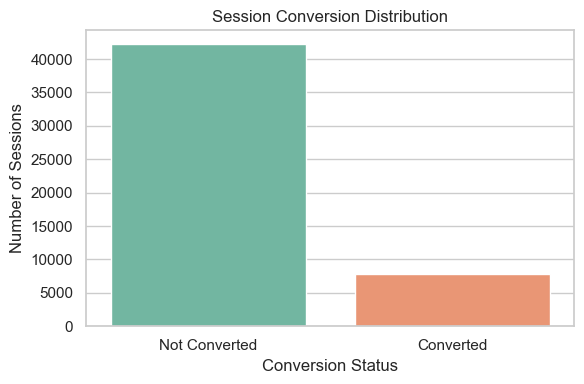

In [27]:
# Conversion Distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=sessions,
    x="converted",
    hue="converted",
    palette="Set2",
    legend=False
)

plt.title("Session Conversion Distribution")
plt.xlabel("Conversion Status")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["Not Converted", "Converted"])

plt.tight_layout()
plt.show()

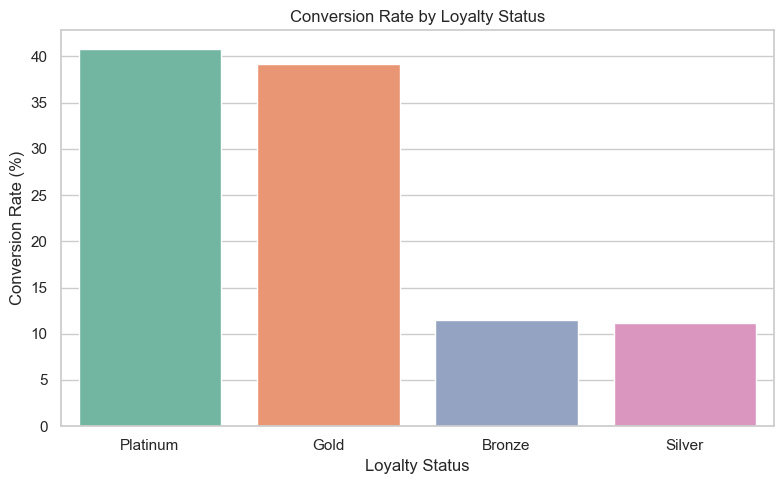

,loyalty_status,converted
2,Platinum,40.770878
1,Gold,39.157206
0,Bronze,11.433098
3,Silver,11.199671


In [28]:
# Conversion Rate by Loyalty Status

conversion_by_loyalty = (
    sessions.groupby("loyalty_status")["converted"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("converted", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=conversion_by_loyalty,
    x="loyalty_status",
    y="converted",
    hue="loyalty_status",
    palette="Set2",
    legend=False
)

plt.title("Conversion Rate by Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

display(conversion_by_loyalty)

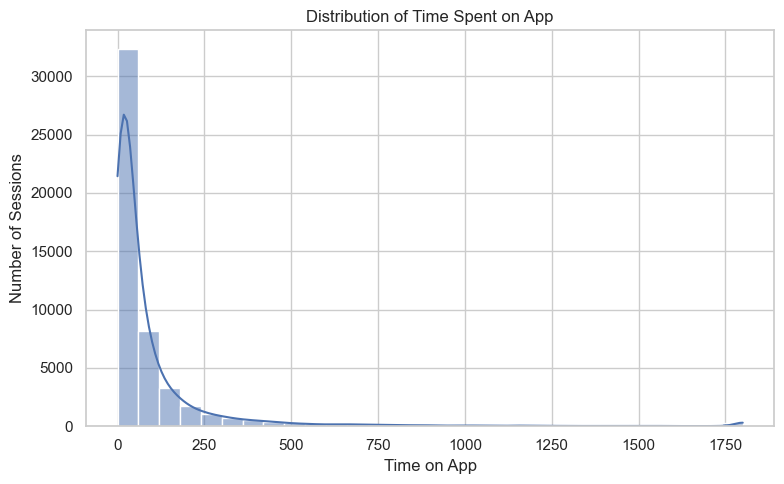

In [29]:
# Time on App Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=sessions,
    x="time_on_app",
    bins=30,
    kde=True
)

plt.title("Distribution of Time Spent on App")
plt.xlabel("Time on App")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

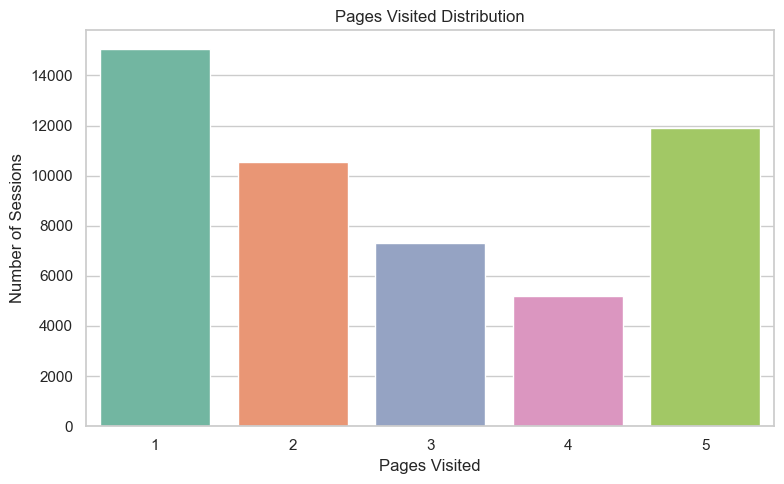

In [30]:
# Pages Visited Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=sessions,
    x="pages_visited",
    hue="pages_visited",
    palette="Set2",
    legend=False
)

plt.title("Pages Visited Distribution")
plt.xlabel("Pages Visited")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

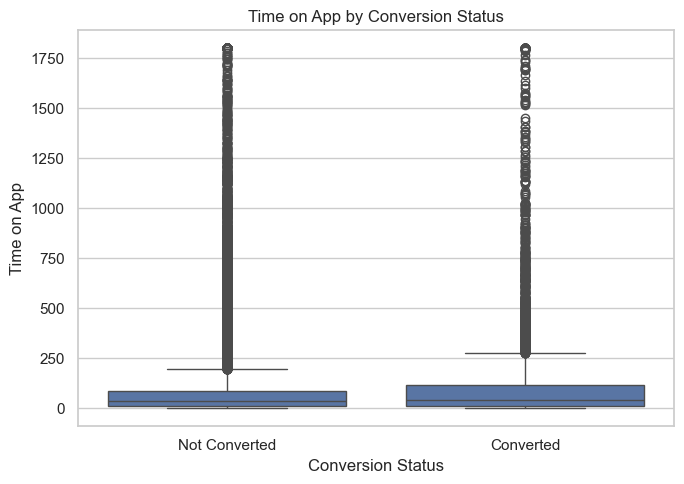

In [31]:
# Time on App by Conversion Status

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=sessions,
    x="converted",
    y="time_on_app"
)

plt.title("Time on App by Conversion Status")
plt.xlabel("Conversion Status")
plt.ylabel("Time on App")
plt.xticks([0, 1], ["Not Converted", "Converted"])

plt.tight_layout()
plt.show()

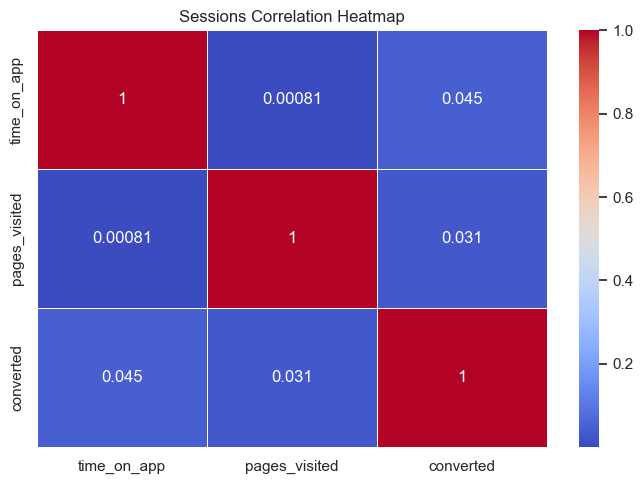

In [32]:
# Sessions Correlation Heatmap

session_numeric_cols = sessions.select_dtypes(include="number")

plt.figure(figsize=(7, 5))

sns.heatmap(
    session_numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Sessions Correlation Heatmap")

plt.tight_layout()
plt.show()

In [33]:
# =====================================================
# EDA 4: Drivers Dataset
# =====================================================

dataset_overview(drivers, "Drivers")

DRIVERS DATASET OVERVIEW
Shape: (4772, 7)

Columns:
['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active', 'city', 'acceptance_rate']

Missing values:
driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64

Duplicate rows: 0


,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
1,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
2,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
3,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773
4,D00005,3.1,Sedan,2024-09-27,2024-12-15 23:26:07.576316,Nairobi,0.874726


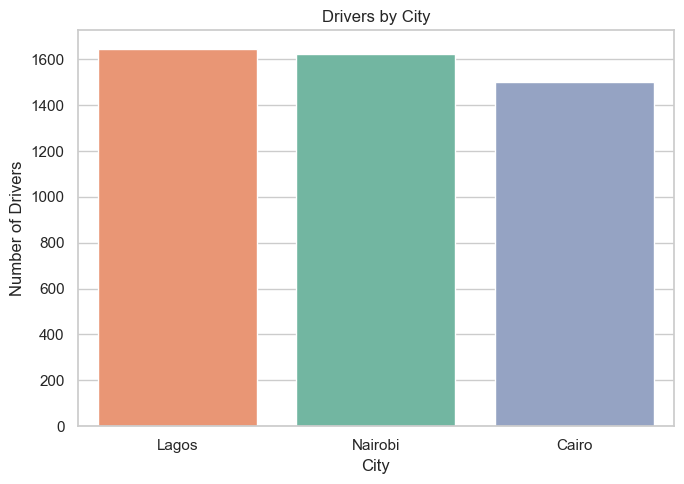

In [34]:
# Drivers by City

plt.figure(figsize=(7, 5))

sns.countplot(
    data=drivers,
    x="city",
    hue="city",
    order=drivers["city"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Drivers by City")
plt.xlabel("City")
plt.ylabel("Number of Drivers")

plt.tight_layout()
plt.show()

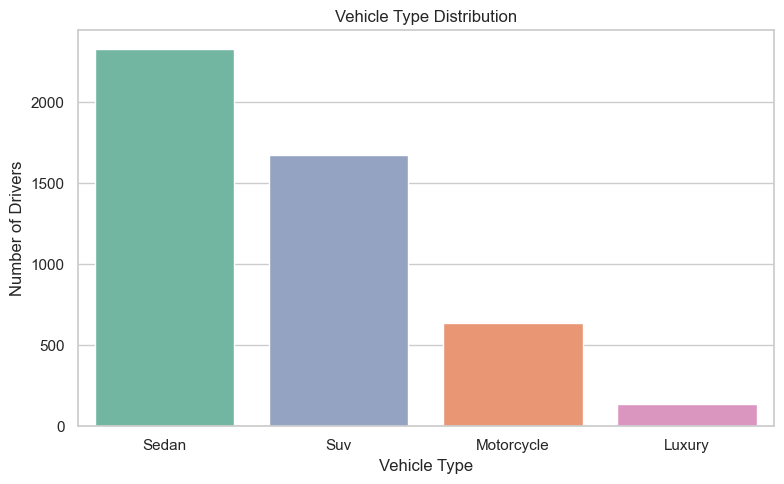

In [35]:
# Vehicle Type Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=drivers,
    x="vehicle_type",
    hue="vehicle_type",
    order=drivers["vehicle_type"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Drivers")

plt.tight_layout()
plt.show()

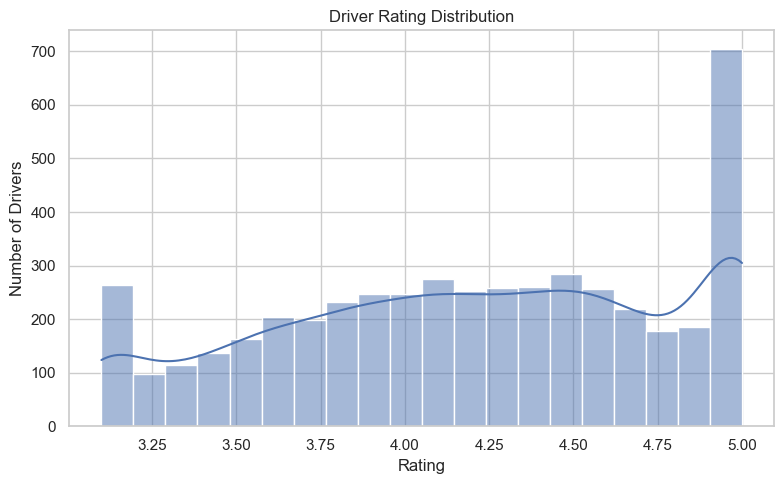

In [36]:
# Driver Rating Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=drivers,
    x="rating",
    bins=20,
    kde=True
)

plt.title("Driver Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Drivers")

plt.tight_layout()
plt.show()

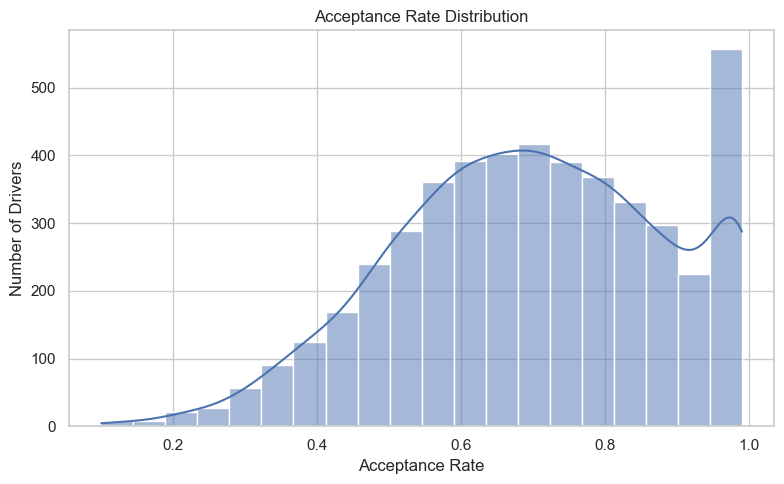

In [37]:
# Acceptance Rate Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=drivers,
    x="acceptance_rate",
    bins=20,
    kde=True
)

plt.title("Acceptance Rate Distribution")
plt.xlabel("Acceptance Rate")
plt.ylabel("Number of Drivers")

plt.tight_layout()
plt.show()

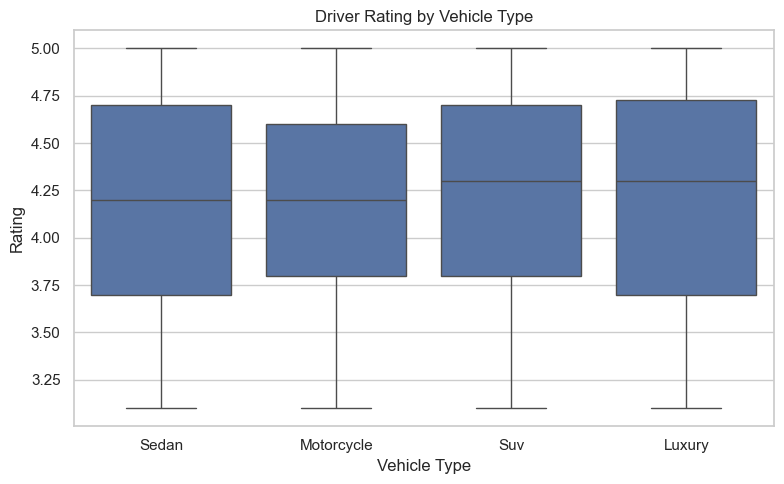

In [38]:
# Rating by Vehicle Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=drivers,
    x="vehicle_type",
    y="rating"
)

plt.title("Driver Rating by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

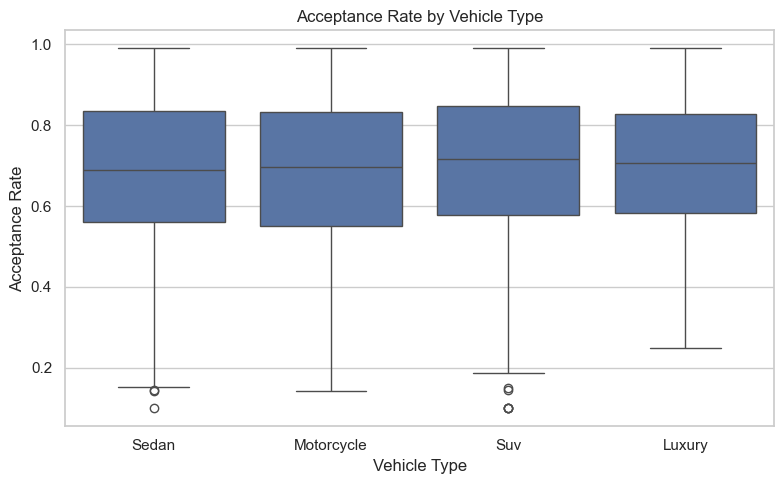

In [39]:
# Acceptance Rate by Vehicle Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=drivers,
    x="vehicle_type",
    y="acceptance_rate"
)

plt.title("Acceptance Rate by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Acceptance Rate")

plt.tight_layout()
plt.show()

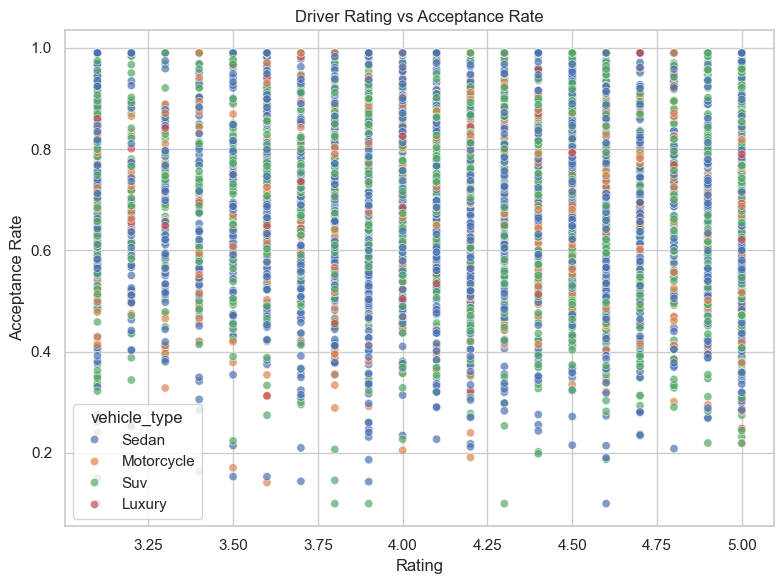

In [40]:
# Rating vs Acceptance Rate

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=drivers,
    x="rating",
    y="acceptance_rate",
    hue="vehicle_type",
    alpha=0.7
)

plt.title("Driver Rating vs Acceptance Rate")
plt.xlabel("Rating")
plt.ylabel("Acceptance Rate")

plt.tight_layout()
plt.show()

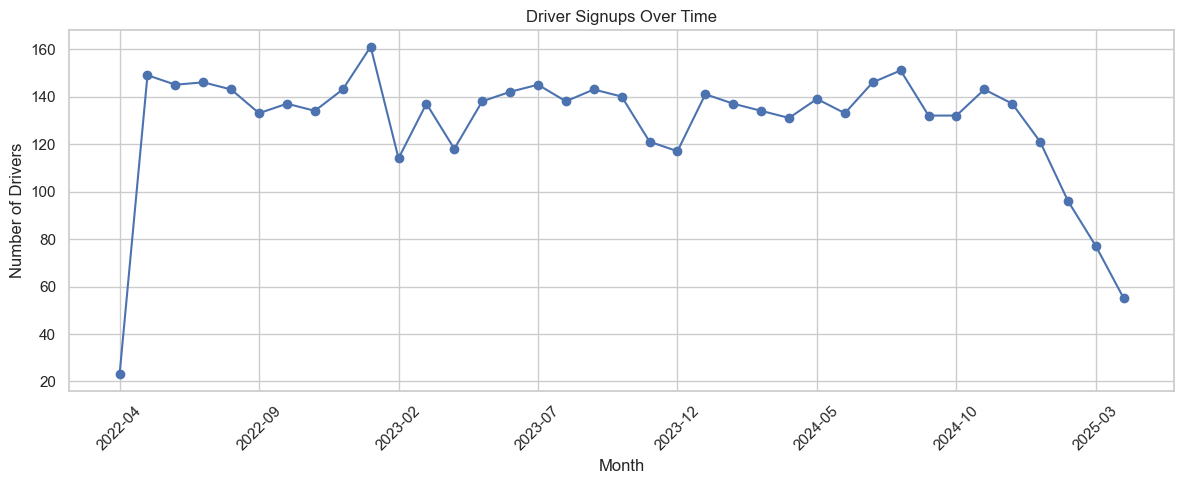

In [41]:
# Driver Signups Over Time

driver_signups = (
    drivers
    .groupby(drivers["signup_date"].dt.to_period("M"))
    .size()
)

driver_signups.index = driver_signups.index.astype(str)

plt.figure(figsize=(12, 5))

driver_signups.plot(kind="line", marker="o")

plt.title("Driver Signups Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

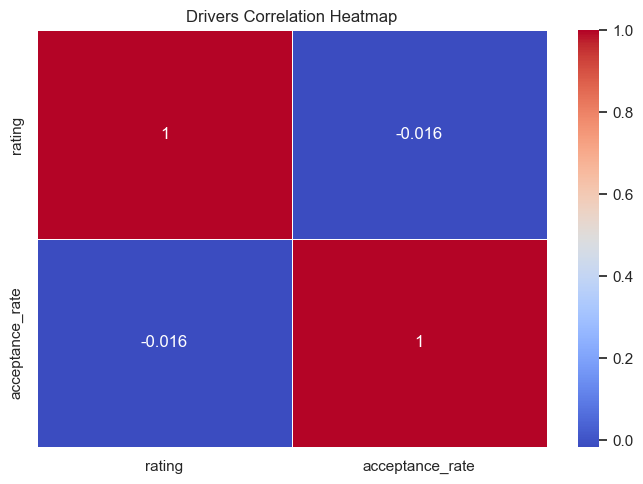

In [42]:
# Drivers Correlation Heatmap

driver_numeric_cols = drivers.select_dtypes(include="number")

plt.figure(figsize=(7, 5))

sns.heatmap(
    driver_numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Drivers Correlation Heatmap")

plt.tight_layout()
plt.show()

In [43]:
# =====================================================
# EDA 5: Promotions Dataset
# =====================================================

dataset_overview(promotions, "Promotions")

PROMOTIONS DATASET OVERVIEW
Shape: (20, 12)

Columns:
['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date', 'end_date', 'target_segment', 'city_scope', 'ab_test_groups', 'test_allocation', 'success_metric', 'promo_duration_days']

Missing values:
promo_id               0
promo_name             0
promo_type             0
promo_value            0
start_date             0
end_date               0
target_segment         0
city_scope             0
ab_test_groups         0
test_allocation        0
success_metric         0
promo_duration_days    0
dtype: int64

Duplicate rows: 0


,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric,promo_duration_days
0,P000,Peak Hour Pass,Surge_Waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency,29
1,P001,Peak Hour Pass,Surge_Waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate,26
2,P002,Peak Hour Pass,Surge_Waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Roi,20
3,P003,Loyalty Bonus,Points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate,8
4,P004,Loyalty Bonus,Points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency,19


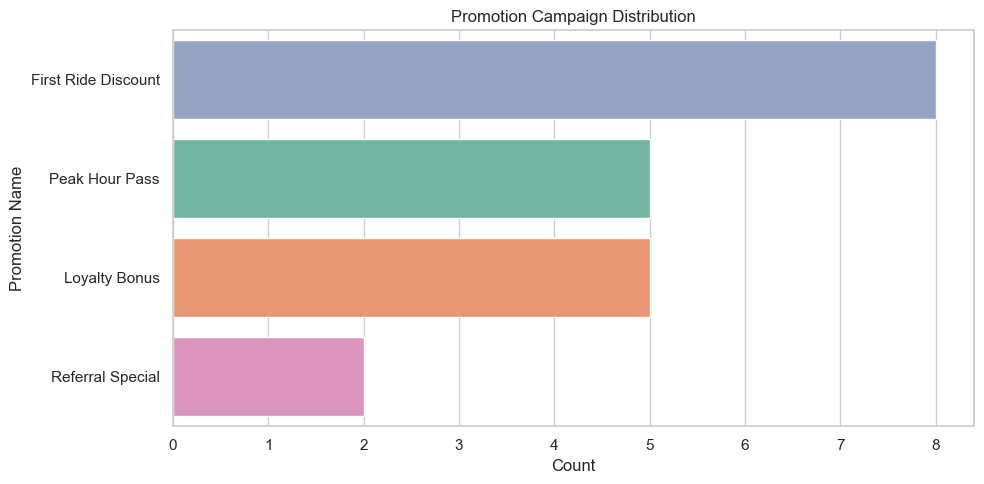

In [44]:
# Promotion Name Distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=promotions,
    y="promo_name",
    hue="promo_name",
    order=promotions["promo_name"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Promotion Campaign Distribution")
plt.xlabel("Count")
plt.ylabel("Promotion Name")

plt.tight_layout()
plt.show()

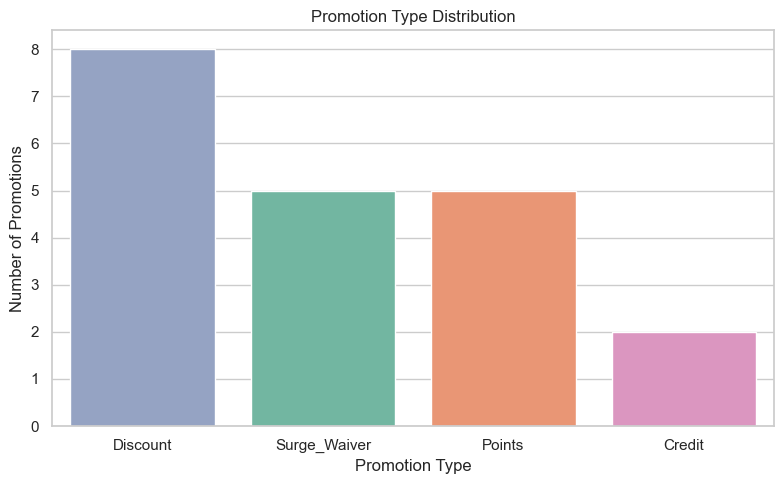

In [45]:
# Promotion Type Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=promotions,
    x="promo_type",
    hue="promo_type",
    order=promotions["promo_type"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Promotion Type Distribution")
plt.xlabel("Promotion Type")
plt.ylabel("Number of Promotions")

plt.tight_layout()
plt.show()

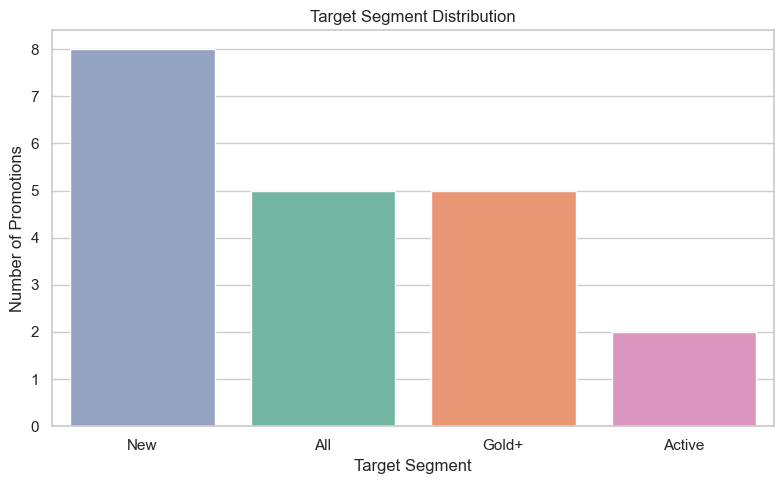

In [46]:
# Target Segment Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=promotions,
    x="target_segment",
    hue="target_segment",
    order=promotions["target_segment"].value_counts().index,
    palette="Set2",
    legend=False
)

plt.title("Target Segment Distribution")
plt.xlabel("Target Segment")
plt.ylabel("Number of Promotions")

plt.tight_layout()
plt.show()

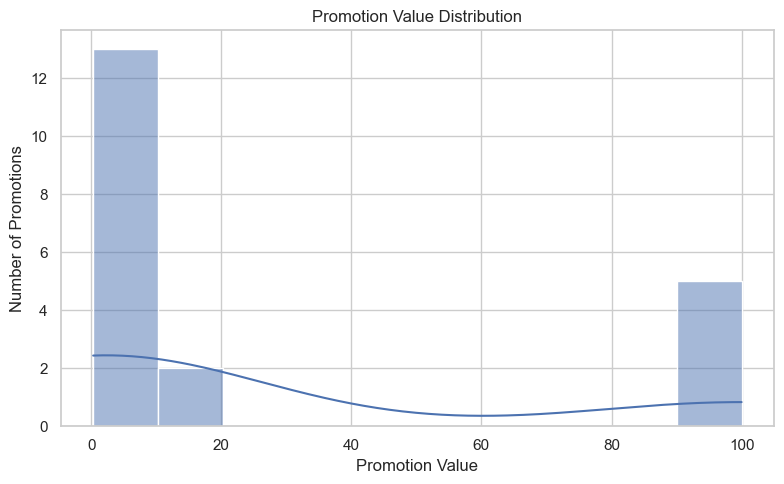

In [47]:
# Promotion Value Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=promotions,
    x="promo_value",
    bins=10,
    kde=True
)

plt.title("Promotion Value Distribution")
plt.xlabel("Promotion Value")
plt.ylabel("Number of Promotions")

plt.tight_layout()
plt.show()

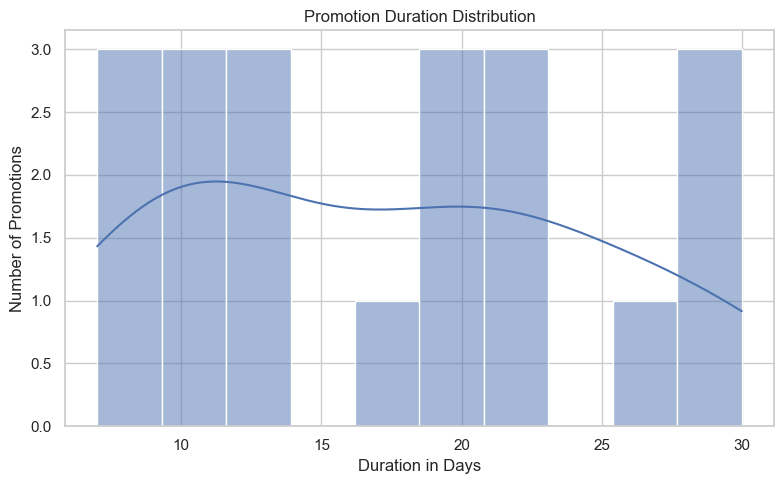

In [48]:
# Promotion Duration Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=promotions,
    x="promo_duration_days",
    bins=10,
    kde=True
)

plt.title("Promotion Duration Distribution")
plt.xlabel("Duration in Days")
plt.ylabel("Number of Promotions")

plt.tight_layout()
plt.show()

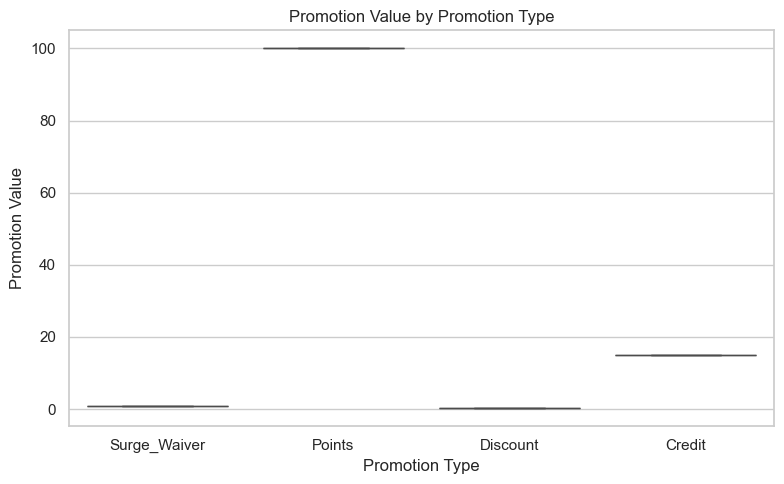

In [49]:
# Promotion Value by Promotion Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=promotions,
    x="promo_type",
    y="promo_value"
)

plt.title("Promotion Value by Promotion Type")
plt.xlabel("Promotion Type")
plt.ylabel("Promotion Value")

plt.tight_layout()
plt.show()

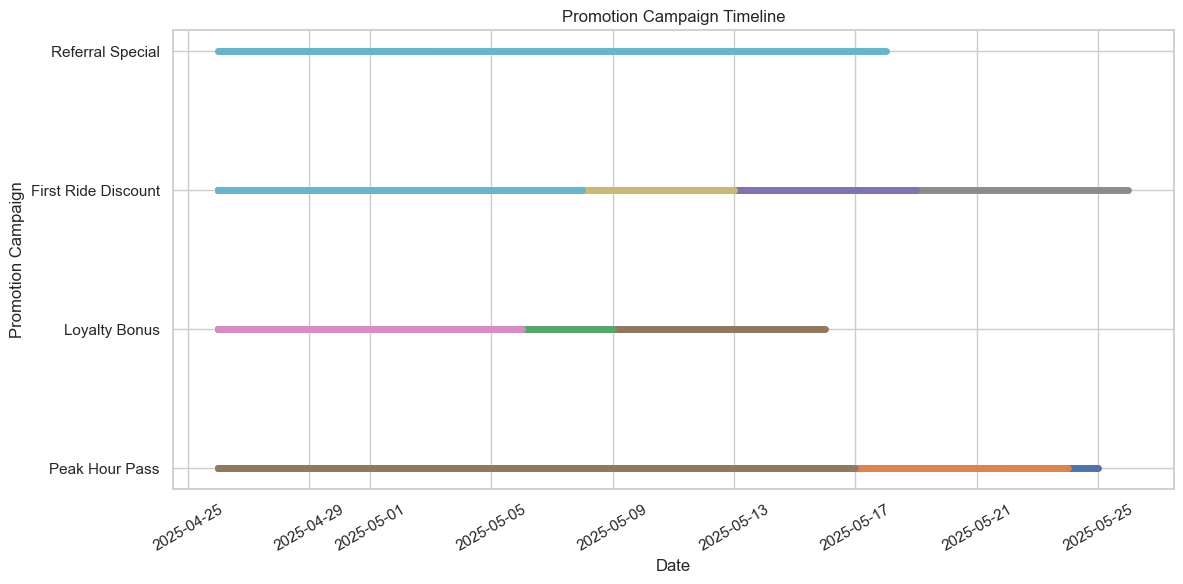

In [50]:
# Promotion Timeline

plt.figure(figsize=(12, 6))

for _, row in promotions.iterrows():
    plt.plot(
        [row["start_date"], row["end_date"]],
        [row["promo_name"], row["promo_name"]],
        linewidth=5
    )

plt.title("Promotion Campaign Timeline")
plt.xlabel("Date")
plt.ylabel("Promotion Campaign")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

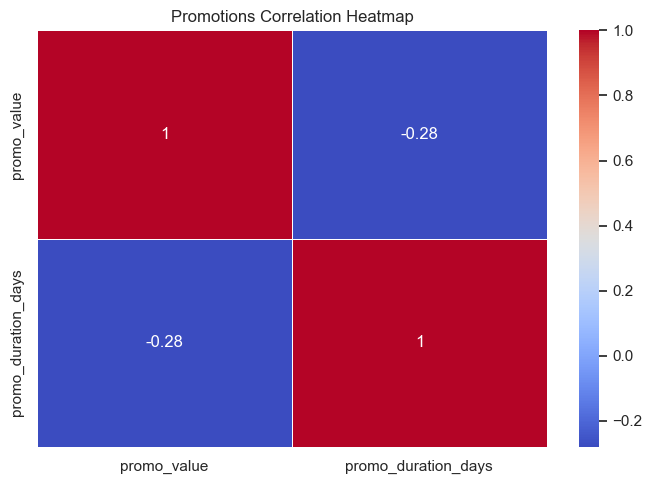

In [51]:
# Promotions Correlation Heatmap

promotion_numeric_cols = promotions.select_dtypes(include="number")

plt.figure(figsize=(7, 5))

sns.heatmap(
    promotion_numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Promotions Correlation Heatmap")

plt.tight_layout()
plt.show()